<a href="https://colab.research.google.com/github/gustavozonato/BANCO-DE-DADOS/blob/main/BD41.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Iniciando Experimento de Performance de Dados...

RESULTADOS DO EXPERIMENTO:
 Volume de Dados (Registros)  Busca Linear (ms)  Busca Indexada (ms)  Ganho de Performance (%)
                       10000             1.0678               0.0040                  26748.85
                       50000             2.3100               0.0057                  40504.26
                      100000             4.6049               0.0041                 112781.17
                      500000            21.6383               0.0052                 412471.92
                     1000000            44.8802               0.0051                 886785.20


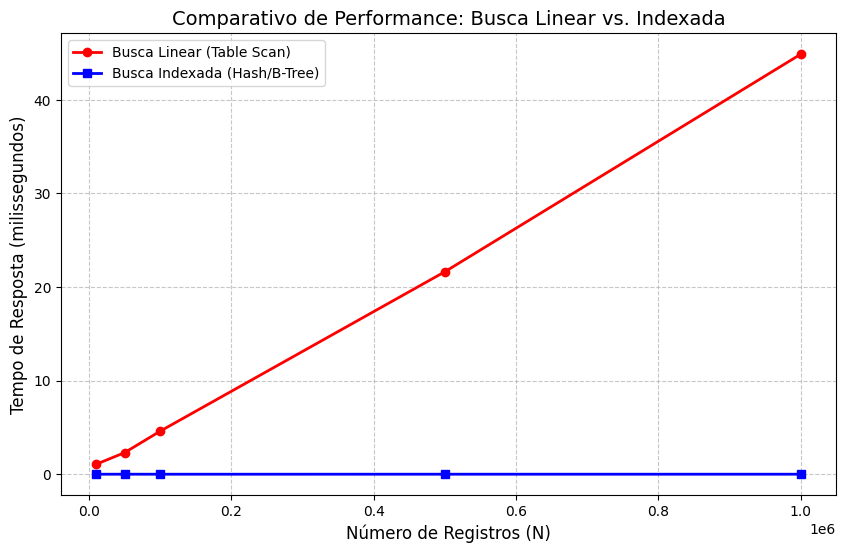


[INFO] Gráfico salvo como 'grafico.png' com sucesso.


In [3]:
import pandas as pd
import time
import matplotlib.pyplot as plt
import random

def simular_experimento():
    """
    Executa o benchmark comparando busca linear (Table Scan)
    e busca indexada (Hash Map/Index).
    """
    volumes = [10000, 50000, 100000, 500000, 1000000]
    resultados = []

    for n in volumes:
        # 1. Gerar dados sintéticos
        dados_lista = [f"ID_{i}" for i in range(n)]
        dados_indice = {id_val: i for i, id_val in enumerate(dados_lista)}

        # Alvo da busca (pior caso: último elemento)
        alvo = f"ID_{n-1}"

        # 2. Benchmark: Busca Linear (Sem Índice)
        inicio = time.perf_counter_ns()
        for item in dados_lista:
            if item == alvo:
                break
        fim = time.perf_counter_ns()
        tempo_linear = (fim - inicio) / 1e6  # Converter para milissegundos

        # 3. Benchmark: Busca Indexada
        inicio = time.perf_counter_ns()
        _ = dados_indice.get(alvo)
        fim = time.perf_counter_ns()
        tempo_indexado = (fim - inicio) / 1e6 # Converter para milissegundos

        resultados.append({
            "Volume de Dados (Registros)": n,
            "Busca Linear (ms)": round(tempo_linear, 4),
            "Busca Indexada (ms)": round(tempo_indexado, 4),
            "Ganho de Performance (%)": round((tempo_linear / tempo_indexado * 100), 2) if tempo_indexado > 0 else 0
        })

    return pd.DataFrame(resultados)

def gerar_visualizacao(df):
    """
    Gera o gráfico comparativo e salva como grafico.png.
    """
    plt.figure(figsize=(10, 6))
    plt.plot(df["Volume de Dados (Registros)"], df["Busca Linear (ms)"],
             marker='o', label='Busca Linear (Table Scan)', color='red', linewidth=2)
    plt.plot(df["Volume de Dados (Registros)"], df["Busca Indexada (ms)"],
             marker='s', label='Busca Indexada (Hash/B-Tree)', color='blue', linewidth=2)

    plt.title('Comparativo de Performance: Busca Linear vs. Indexada', fontsize=14)
    plt.xlabel('Número de Registros (N)', fontsize=12)
    plt.ylabel('Tempo de Resposta (milissegundos)', fontsize=12)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)

    # Salvar o gráfico para o artigo
    plt.savefig('grafico.png', dpi=300)
    plt.show()
    print("\n[INFO] Gráfico salvo como 'grafico.png' com sucesso.")

# --- EXECUÇÃO DO EXPERIMENTO ---
print("Iniciando Experimento de Performance de Dados...\n")
df_resultados = simular_experimento()
print("RESULTADOS DO EXPERIMENTO:")
print(df_resultados.to_string(index=False))
gerar_visualizacao(df_resultados)